# Overview
In this final project you will design and implement a complete recommendation system pipeline from scratch. Recommendation systems are one of the most impactful applications of data mining, powering platforms such as Netflix, Spotify, Amazon, and YouTube. You will apply the three main approaches — Content-Based Filtering, Collaborative Filtering (User-User and Item-Item), and Latent-Factor Matrix Factorization — and rigorously compare their strengths and weaknesses on a real-world dataset.


# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Part 1 — Dataset Loading & Exploratory Data Analysis

## 1.1 Loading & Preprocessing
<ul>
<li>Load all relevant CSV files and merge them appropriately.</li> 
<li>Report the number of users, movies, and ratings. </li>
<li>Handle any missing values or duplicate entries. </li>
<li>Construct the User-Item utility matrix (users × movies) with ratings as values and NaN for unrated pairs.</li> 
<li>Report the sparsity of the utility matrix (% of missing entries).</li> 
</ul>

In [2]:
# Load the CSV files
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')
tags = pd.read_csv('ml-latest-small/tags.csv')
links = pd.read_csv('ml-latest-small/links.csv')

In [3]:
# Merge the ratings x movies DataFrames for the content based filtering
# We use an 'inner' merge on 'movieId' to combine rows where the ID matches in both files
ratings_movies_merged = pd.merge(ratings, movies, on='movieId', how='inner')

# View the result
ratings_movies_merged.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [4]:
# Calculate the number of unique users
correct_num_users = 610
num_users = ratings['userId'].nunique()

# Calculate the number of unique movies
num_movies = movies['movieId'].nunique()
correct_num_movies = 9742

# Calculate the total number of ratings given
num_ratings = len(ratings)
correct_num_ratings = 100836

# Print out the report
print(f"Total number of Users: {num_users}")
print(f"CORRECT Total number of Users FROM WEBSITE: {correct_num_users}")

print("------------------------------------------")

print(f"Total number of Movies: {num_movies}")
print(f"CORRECT Total number of FROM WEBSITE: {correct_num_movies}")

print("------------------------------------------")

print(f"Total number of Ratings: {num_ratings}")
print(f"CORRECT Total number of FROM WEBSITE: {correct_num_ratings}")

Total number of Users: 610
CORRECT Total number of Users FROM WEBSITE: 610
------------------------------------------
Total number of Movies: 9742
CORRECT Total number of FROM WEBSITE: 9742
------------------------------------------
Total number of Ratings: 100836
CORRECT Total number of FROM WEBSITE: 100836


In [5]:
# --- Check for Missing Values ---
print("Missing values in Ratings:")
print(ratings.isnull().sum())
print("\nMissing values in Movies:")
print(movies.isnull().sum())
print("\nMissing values in Tags:")
print(tags.isnull().sum())
print("\nMissing values in Links:")
print(links.isnull().sum())

# --- Check for Duplicate Rows ---
duplicates_ratings = ratings.duplicated().sum()
duplicates_movies = movies.duplicated().sum()
duplicates_tags = tags.duplicated().sum()
duplicates_links = links.duplicated().sum()

print(f"\nDuplicate rows in Ratings: {duplicates_ratings}")
print(f"Duplicate rows in Movies: {duplicates_movies}")
print(f"Duplicate rows in Tags: {duplicates_tags}")
print(f"Duplicate rows in Links: {duplicates_links}")

Missing values in Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in Movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in Tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Missing values in Links:
movieId    0
imdbId     0
tmdbId     8
dtype: int64

Duplicate rows in Ratings: 0
Duplicate rows in Movies: 0
Duplicate rows in Tags: 0
Duplicate rows in Links: 0


In [6]:
# --- 1. Construct the User-Item Utility Matrix ---
# Rows will be users, columns will be movies, and the cells will hold the ratings.
# Unrated pairs will automatically be filled with NaN.
utility_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

# Let's take a quick look at the top-left corner of the matrix
print("Utility Matrix (First 10 users and movies):")
print(utility_matrix.iloc[:10, :10])
print("\n")

# --- 2. Calculate the Sparsity of the Matrix ---
# Total number of possible ratings (Rows x Columns)
total_elements = utility_matrix.size

# Total number of missing ratings (NaNs)
missing_entries = utility_matrix.isnull().sum().sum()

# Calculate the percentage
sparsity = (missing_entries / total_elements) * 100

print(f"Total elements in matrix: {total_elements}")
print(f"Total missing entries: {missing_entries}")
print(f"Total populated entries: {total_elements - missing_entries}")
print(f"Matrix Sparsity: {sparsity:.2f}%")

Utility Matrix (First 10 users and movies):
movieId   1    2    3    4    5    6    7    8   9    10
userId                                                  
1        4.0  NaN  4.0  NaN  NaN  4.0  NaN  NaN NaN  NaN
2        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  NaN
3        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  NaN
4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  NaN
5        4.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  NaN
6        NaN  4.0  5.0  3.0  5.0  4.0  4.0  3.0 NaN  3.0
7        4.5  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  NaN
8        NaN  4.0  NaN  NaN  NaN  NaN  NaN  NaN NaN  2.0
9        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  NaN
10       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN NaN  NaN


Total elements in matrix: 5931640
Total missing entries: 5830804
Total populated entries: 100836
Matrix Sparsity: 98.30%


## 1.2 Exploratory Analysis
<ul>
<li>Plot the distribution of ratings (histogram). Comment on any skew.</li>
<li>Plot the distribution of ratings per user and ratings per movie. Identify power-law behaviour.</li>
<li>Visualize the genre distribution across all movies.</li>
<li>Identify and discuss the cold-start problem: how many users have fewer than 5 ratings?
How many movies?</li>
<li>Apply mean-centering to the utility matrix (subtract each user's mean rating from their
ratings) and show how this changes the distribution.</li>
</ul>

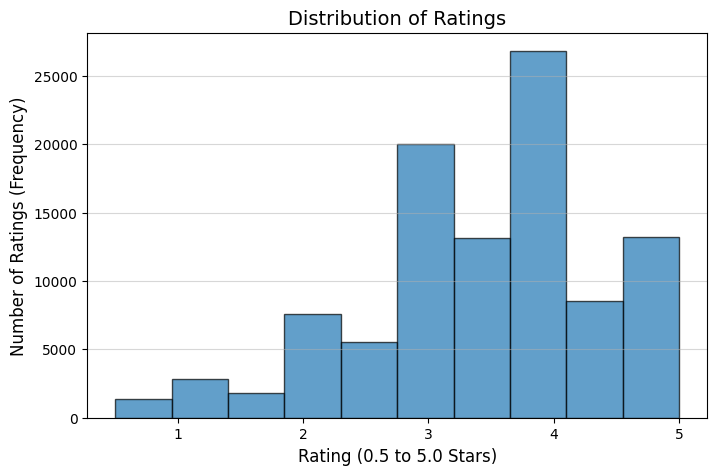

In [7]:
# Create the histogram
plt.figure(figsize=(8, 5))
# We use 10 bins because ratings go from 0.5 to 5.0 in increments of 0.5
plt.hist(ratings['rating'], bins=10, edgecolor='black', alpha=0.7)

# Add labels and title
plt.title('Distribution of Ratings', fontsize=14)
plt.xlabel('Rating (0.5 to 5.0 Stars)', fontsize=12)
plt.ylabel('Number of Ratings (Frequency)', fontsize=12)

# Show a subtle grid behind the bars for easier reading
plt.grid(axis='y', alpha=0.5)
plt.show()

Left-Skewed Distribution: The data is heavily skewed to the left (negative skew). The vast majority of ratings are concentrated on the higher end of the scale, specifically between 3.0 and 5.0. This indicates that users generally tend to give positive ratings. This is a common phenomenon in recommender systems, often caused by selection bias—users tend to watch and rate movies they already think they will like rather than forcing themselves to watch something they expect to rate poorly.

Why does this happen? This is a classic psychological phenomenon in recommender systems known as Selection Bias. People generally choose to watch movies they already expect to like (based on trailers, genres, or actors). Therefore, the movies they actually end up rating are usually pretty good. People rarely force themselves to watch a movie they think will be a 1-star experience just to rate it.

Whole-Star Preference: There is a very clear and consistent preference for whole-star ratings over half-star ratings. You can see distinct spikes at 3.0, 4.0, and 5.0, which are significantly taller than the bars for 2.5, 3.5, and 4.5. This suggests that when making a qualitative judgment, users default to round numbers rather than using the granular half-step increments.

Mode: The most frequent rating given by users is 4.0 stars (peaking above 25,000), followed by 3.0 stars and then 5.0 stars.

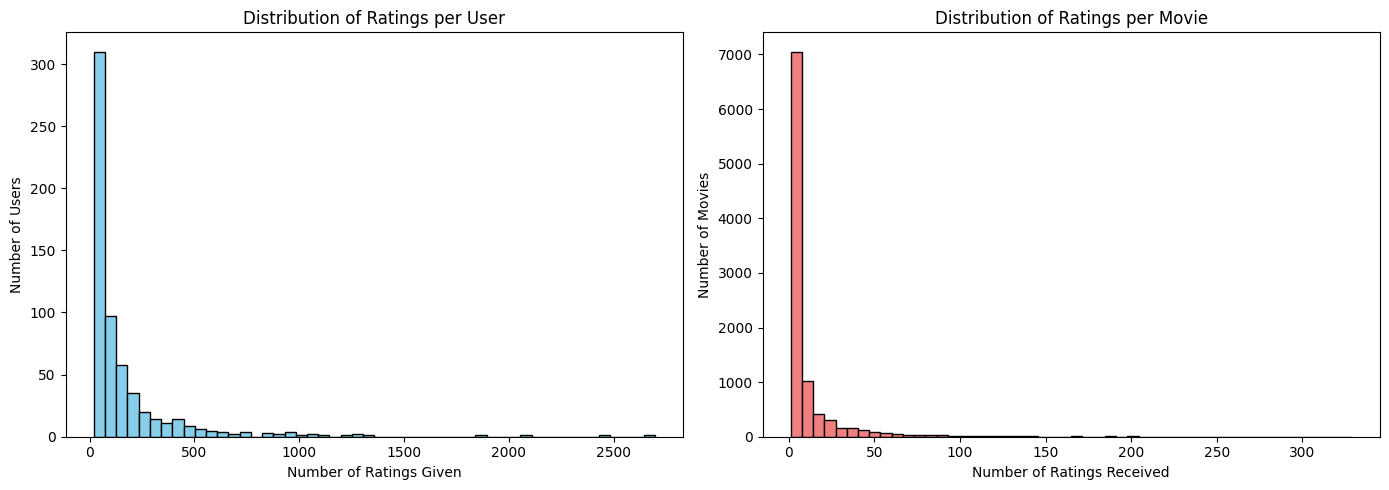

In [8]:
# 1. Count the number of ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()

# 2. Count the number of ratings per movie
ratings_per_movie = ratings.groupby('movieId')['rating'].count()

# 3. Set up the plotting area (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Ratings per User ---
axes[0].hist(ratings_per_user, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Ratings per User')
axes[0].set_xlabel('Number of Ratings Given')
axes[0].set_ylabel('Number of Users')
# Optional: 
# axes[0].set_yscale('log') # Uncomment this to see the straight-line power law!

# --- Plot 2: Ratings per Movie ---
axes[1].hist(ratings_per_movie, bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Ratings per Movie')
axes[1].set_xlabel('Number of Ratings Received')
axes[1].set_ylabel('Number of Movies')
# Optional:
# axes[1].set_yscale('log') # Uncomment this to see the straight-line power law!

plt.tight_layout()
plt.show()

- The Extreme Spike: Almost all the volume on the graph is crammed against the far-left y-axis. This tells us that the most common behavior for a user is to rate very few movies, and the most common state for a movie is to have very few ratings.

- The Long Empty Tail: The x-axis stretches out very far to the right to accommodate that one user who rated 2,000+ movies, or that one mega-hit movie with hundreds of ratings, leaving mostly empty white space above the axis.

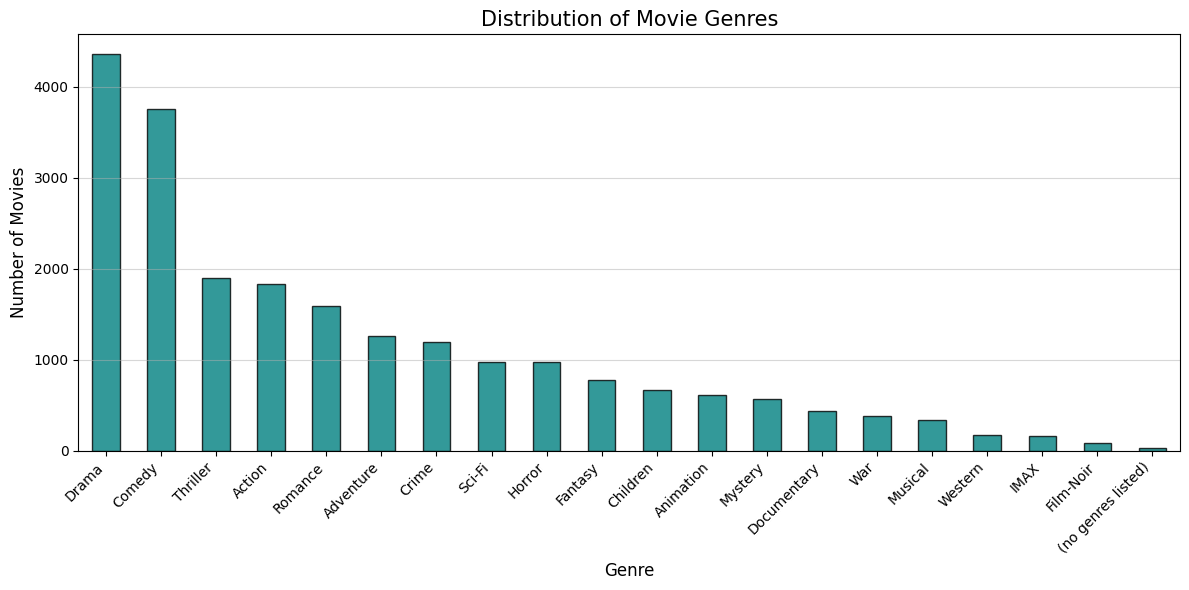

In [9]:
# 1. Split the genres string into a list, then 'explode' it 
# Explode takes a list inside a cell and creates a new row for each item in that list
genres_expanded = movies['genres'].str.split('|').explode()

# 2. Count the total occurrences of each individual genre
genre_counts = genres_expanded.value_counts()

# 3. Create the Bar Chart
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='teal', edgecolor='black', alpha=0.8)

# Add titles and labels
plt.title('Distribution of Movie Genres', fontsize=15)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)

# Adjust layout to make sure labels fit nicely
plt.tight_layout()
plt.show()

In [10]:
# Filter for those with fewer than 5 ratings
users_under_5 = (ratings_per_user < 5).sum()
movies_under_5 = (ratings_per_movie < 5).sum()

# 3. Calculate the percentages to see the scale of the problem
percent_users_under_5 = (users_under_5 / len(ratings_per_user)) * 100
percent_movies_under_5 = (movies_under_5 / len(ratings_per_movie)) * 100

print(f"Users with fewer than 5 ratings: {users_under_5} ({percent_users_under_5:.2f}%)")
print(f"Movies with fewer than 5 ratings: {movies_under_5} ({percent_movies_under_5:.2f}%)")

Users with fewer than 5 ratings: 0 (0.00%)
Movies with fewer than 5 ratings: 6074 (62.46%)


1. The User Cold-Start Problem (New Users):
- If a user has only rated 1 or 2 movies, the algorithm simply does not have enough information to map out their specific tastes.

- Why it's a problem: Collaborative filtering relies on finding "similar" users. If you've only rated The Matrix, you are mathematically similar to millions of other people who also liked The Matrix, making it impossible to give you a personalized recommendation.

- How it's handled: Platforms usually force new users to pick a few genres or rate a few popular items during onboarding to get them past this < 5 rating threshold immediately.

2. The Item Cold-Start Problem (New Movies):
If a newly added movie has fewer than 5 ratings, the system has no idea which users would enjoy it.

- Why it's a problem: In Collaborative Filtering, an item is recommended based on who liked it. If nobody has rated it, it gets buried at the bottom of the matrix and never recommended, creating a vicious cycle where it never gets ratings because it never gets recommended.

- How it's handled: This is where Content-Based Filtering shines. Because Content-Based systems look at the movie's features (like genre, director, actors) rather than its ratings, they can immediately recommend a brand new action movie to users who love action movies, giving it the initial traction it needs.

Utility Matrix (First 5 users and movies):
movieId    1   2    3   4   5
userId                       
1        4.0 NaN  4.0 NaN NaN
2        NaN NaN  NaN NaN NaN
3        NaN NaN  NaN NaN NaN
4        NaN NaN  NaN NaN NaN
5        4.0 NaN  NaN NaN NaN


Mean-Centered Utility Matrix (First 5 users and movies):
movieId         1   2         3   4   5
userId                                 
1       -0.366379 NaN -0.366379 NaN NaN
2             NaN NaN       NaN NaN NaN
3             NaN NaN       NaN NaN NaN
4             NaN NaN       NaN NaN NaN
5        0.363636 NaN       NaN NaN NaN




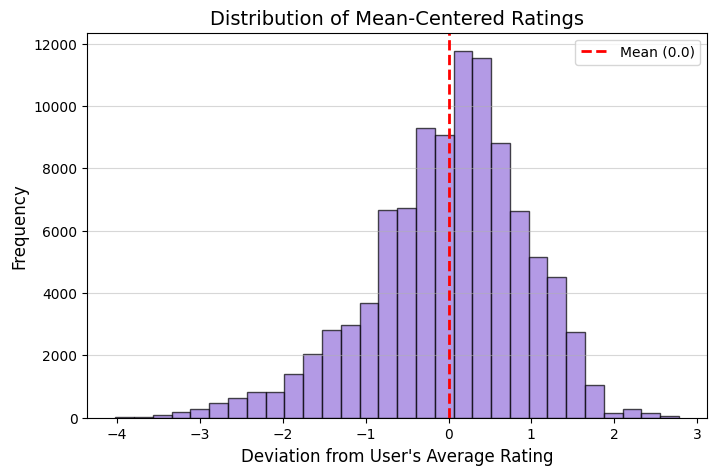

In [11]:
# 1. Calculate the mean rating for each user (the average of each row)
# We use axis=1 to calculate the mean across the columns (movies) for each user
user_means = utility_matrix.mean(axis=1)

# 2. Subtract the user's mean from their ratings
# axis=0 ensures we align the subtraction correctly with the user index
centered_utility_matrix = utility_matrix.sub(user_means, axis=0)

# Let's take a quick look at the centered matrix
print("Utility Matrix (First 5 users and movies):")
print(utility_matrix.iloc[:5, :5])
print("\n")

# Let's take a quick look at the centered matrix
print("Mean-Centered Utility Matrix (First 5 users and movies):")
print(centered_utility_matrix.iloc[:5, :5])
print("\n")

# 3. Extract all the non-NaN values to plot the new distribution
# Flatten the matrix into a 1D array, then filter out the NaNs
centered_ratings = centered_utility_matrix.values.flatten()
centered_ratings = centered_ratings[~np.isnan(centered_ratings)]

# 4. Plot the new distribution
plt.figure(figsize=(8, 5))
plt.hist(centered_ratings, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)

# Add labels and a vertical line at 0 for reference
plt.title('Distribution of Mean-Centered Ratings', fontsize=14)
plt.xlabel('Deviation from User\'s Average Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Mean (0.0)')
plt.legend()

plt.grid(axis='y', alpha=0.5)
plt.show()

Mean-centering solves the problem of User Bias
- Before (Original Histogram): The data was highly left-skewed, clumped up around 3.0, 4.0, and 5.0.

- After (Mean-Centered Histogram): The data now looks much more like a standard "bell curve" (a normal distribution) perfectly centered at 0.0.

# Part 2 - Content-Based Filtering

## 2.1 Item Profile Construction

Build an item profile for each movie based on its genre information. Each movie should be represented as a binary (or weighted) feature vector over all possible genres.

*   Extract all unique genres and build a genre vector per movie.
*   Additionally, incorporate the movie's average rating and number of ratings as additional features.
*   (Optional enrichment) If you choose to use the tags.csv file, apply TF-IDF to the tags to generate a richer item representation and concatenate it with the genre features.

**Note:** *You may use sklearn's TfidfVectorizer only for TF-IDF computation; the item profile assembly must be done manually.*

In [ ]:
import pandas as pd

unique_genres = set()
for genre_string in ratings_movies_merged['genres'].unique():
    unique_genres.update(genre_string.split('|'))
unique_genres = sorted(list(unique_genres))

item_profiles = ratings_movies_merged[['movieId', 'title', 'genres']].drop_duplicates(subset='movieId').copy()

for genre in unique_genres:
    item_profiles[genre] = item_profiles['genres'].apply(lambda x: 1 if genre in x.split('|') else 0)

# Incorporate average rating and number of ratings
movie_stats = ratings_movies_merged.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
movie_stats.columns = ['movieId', 'avg_rating', 'num_ratings']

item_profiles = item_profiles.merge(movie_stats, on='movieId')

item_profiles.drop(columns=['genres'], inplace=True)

print(f"Unique genres found: {unique_genres}")
item_profiles.head()

Unique genres found: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,movieId,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,num_ratings
0,1,Toy Story (1995),0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,3.920930,215
1,3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,3.259615,52
2,6,Heat (1995),0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,3.946078,102
3,47,Seven (a.k.a. Se7en) (1995),0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,3.975369,203
4,50,"Usual Suspects, The (1995)",0,0,0,0,0,0,1,0,...,0,0,1,0,0,1,0,0,4.237745,204


## 2.2 User Profile Construction

Build a user profile for each user as a weighted average of the item profiles of the movies they have rated, weighted by their ratings (shifted so that a rating of 3 = neutral).

*   Show an example user profile vector for at least two users.
*   Visualize the user profiles using dimensionality reduction (PCA to 2D) and plot them — do similar users cluster together?

User profiles built for 610 users.
Profile vector length : 22 features
Feature columns       : ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'avg_rating', 'num_ratings']

───────────────────────────────────────────────────────
 User 1  |  232 ratings  |  profile vector:
───────────────────────────────────────────────────────
  num_ratings           +68.0755  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

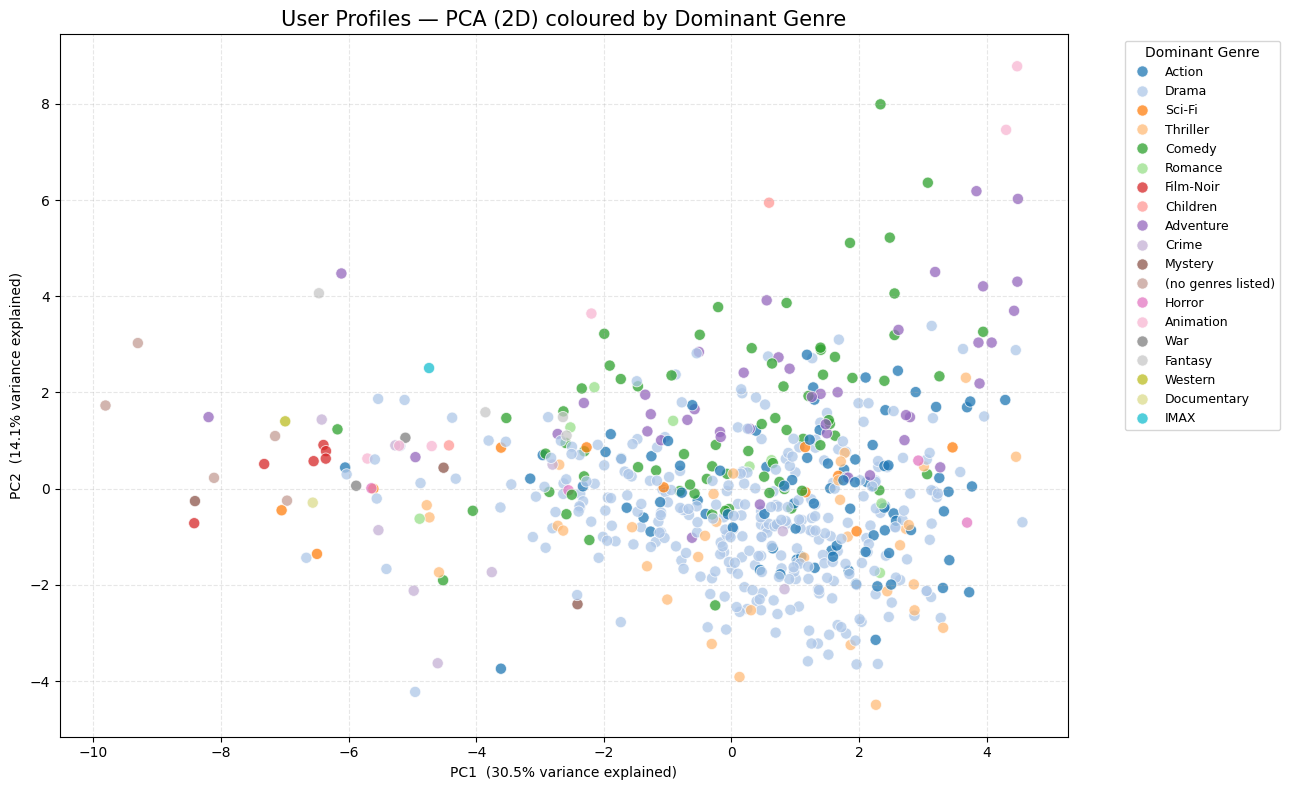

In [22]:

feature_cols = [c for c in item_profiles.columns if c not in ['movieId', 'title']]
ip_indexed   = item_profiles.set_index('movieId')[feature_cols]   

NEUTRAL = 3.0
user_profile_rows = {}

for user_id, group in ratings.groupby('userId'):
    # Keep only movies present in item_profiles
    valid = group[group['movieId'].isin(ip_indexed.index)]
    if valid.empty:
        continue

    weights  = valid['rating'].values - NEUTRAL           # shift: 5→+2, 3→0, 1→-2
    profiles = ip_indexed.loc[valid['movieId'].values].values   # (n, n_features)

    # Weighted average: Σ(wᵢ · pᵢ) / Σ|wᵢ|
    # If user rated everything exactly 3 all weights are 0 → fall back to plain mean
    total_abs = np.sum(np.abs(weights))
    user_vec  = (np.dot(weights, profiles) / total_abs
                 if total_abs > 0
                 else profiles.mean(axis=0))

    user_profile_rows[user_id] = user_vec

user_profiles_df = pd.DataFrame.from_dict(
    user_profile_rows, orient='index', columns=feature_cols
)
user_profiles_df.index.name = 'userId'

print(f"User profiles built for {len(user_profiles_df)} users.")
print(f"Profile vector length : {user_profiles_df.shape[1]} features")
print(f"Feature columns       : {feature_cols}\n")

example_users = user_profiles_df.index[:2].tolist()

for uid in example_users:
    vec     = user_profiles_df.loc[uid]
    n_rated = int((ratings['userId'] == uid).sum())
    print(f"{'─'*55}")
    print(f" User {uid}  |  {n_rated} ratings  |  profile vector:")
    print(f"{'─'*55}")
    # Pretty-print: sort by absolute value so the dominant features stand out
    top = vec.abs().sort_values(ascending=False)
    for feat in top.index:
        bar = '█' * int(abs(vec[feat]) * 20)   # mini bar chart
        sign = '+' if vec[feat] >= 0 else '-'
        print(f"  {feat:<20s}  {sign}{abs(vec[feat]):.4f}  {bar}")
    print()

# Identify genre-only columns (exclude numeric stats)
genre_cols = [c for c in feature_cols if c not in ['avg_rating', 'num_ratings']]

user_profiles_df['top_genre'] = user_profiles_df[genre_cols].idxmax(axis=1)

pca    = PCA(n_components=2, random_state=42)

scaler = StandardScaler()
coords = pca.fit_transform(
    scaler.fit_transform(user_profiles_df.drop(columns=['top_genre']))
)

plot_df             = pd.DataFrame(coords, columns=['PC1', 'PC2'])
plot_df['Top Genre'] = user_profiles_df['top_genre'].values

plt.figure(figsize=(13, 8))
sns.scatterplot(
    data=plot_df, x='PC1', y='PC2',
    hue='Top Genre', palette='tab20',
    alpha=0.75, edgecolor='w', s=65
)
plt.title('User Profiles — PCA (2D) coloured by Dominant Genre', fontsize=15)
plt.xlabel(f'PC1  ({pca.explained_variance_ratio_[0]:.1%} variance explained)')
plt.ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.1%} variance explained)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Dominant Genre',
           fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3 Recommendation & Evaluation

For each user, compute the **cosine similarity** between their user profile and every *unrated* item profile, then surface the top-10 as recommendations.

Evaluation uses **leave-one-out cross-validation (LOO-CV)**:
- Hide each user's last-rated movie (by timestamp).
- Generate top-10 recommendations from the remaining ratings.
- Check whether the held-out movie appears in those 10.

Metrics reported:
- **Precision@10** — fraction of the 10 recommendations that are relevant (i.e. the held-out item).
- **Recall@10** — fraction of relevant items (1 total) recovered in the top 10.

> Because there is exactly one held-out item per user, Precision@10 = (1/10 if hit, else 0) and Recall@10 = (1 if hit, else 0). The averages across all users are the meaningful numbers.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

feature_cols  = [c for c in item_profiles.columns if c not in ['movieId', 'title']]
ip_indexed    = item_profiles.set_index('movieId')[feature_cols]

scaler        = StandardScaler()
ip_scaled     = pd.DataFrame(
    scaler.fit_transform(ip_indexed),
    index=ip_indexed.index, columns=feature_cols
)

up_scaled = pd.DataFrame(
    scaler.transform(user_profiles_df.drop(columns=['top_genre'], errors='ignore')),
    index=user_profiles_df.index, columns=feature_cols
)

# Utility: movies each user has already rated
rated_by = ratings.groupby('userId')['movieId'].apply(set).to_dict()

def top10_for_user(uid):
    """Return a ranked list of (movieId, similarity) for unrated movies."""
    user_vec   = up_scaled.loc[[uid]].values          # (1, n_features)
    sims       = cosine_similarity(user_vec, ip_scaled.values).flatten()
    sim_series = pd.Series(sims, index=ip_scaled.index)
    unrated    = sim_series.drop(index=list(rated_by.get(uid, [])), errors='ignore')
    return unrated.nlargest(10)

# ── Part A: Top-10 recommendations for 3 example users ───────────────────────
example_users = user_profiles_df.index[:3].tolist()

for uid in example_users:
    recs = top10_for_user(uid)
    titles = ip_indexed.index.map(
        item_profiles.set_index('movieId')['title']
    )
    title_map = item_profiles.set_index('movieId')['title']
    print(f"\n{'═'*55}")
    print(f" Top-10 recommendations for User {uid}")
    print(f"{'═'*55}")
    for rank, (mid, score) in enumerate(recs.items(), 1):
        print(f"  {rank:>2}. {title_map.get(mid, mid):<45s}  sim={score:.4f}")

# Hold out each user's LAST-rated movie (by timestamp)
loo_holdout = (
    ratings.sort_values('timestamp')
           .groupby('userId')
           .last()
           .reset_index()[['userId', 'movieId']]
)

NEUTRAL = 3.0
hits = 0

for _, row in loo_holdout.iterrows():
    uid, held_movie = row['userId'], row['movieId']

    # Ratings minus the held-out item
    user_ratings = ratings[
        (ratings['userId'] == uid) & (ratings['movieId'] != held_movie)
    ]
    if user_ratings.empty:
        continue

    # Re-build profile on the fly
    valid   = user_ratings[user_ratings['movieId'].isin(ip_indexed.index)]
    weights = valid['rating'].values - NEUTRAL
    profs   = ip_indexed.loc[valid['movieId'].values].values
    total_w = np.abs(weights).sum()
    user_vec = np.dot(weights, profs) / total_w if total_w > 0 else profs.mean(axis=0)

    # Scale and score ALL unrated movies (excluding the training-rated ones)
    user_vec_scaled = scaler.transform(pd.DataFrame(user_vec.reshape(1, -1), columns=feature_cols))
    sims     = cosine_similarity(user_vec_scaled, ip_scaled.values).flatten()
    sim_ser  = pd.Series(sims, index=ip_scaled.index)

    # Exclude movies rated in training (held-out stays available to be recommended)
    training_rated = set(valid['movieId'].values)
    candidates     = sim_ser.drop(index=list(training_rated), errors='ignore')
    top10_ids      = set(candidates.nlargest(10).index)

    if held_movie in top10_ids:
        hits += 1

n_users      = len(loo_holdout)
precision_10 = hits / (n_users * 10)
recall_10    = hits / n_users

print(f"\n{'═'*45}")
print(f"  LOO-CV Results  ({n_users} users evaluated)")
print(f"{'═'*45}")
print(f"  Hits (held-out movie in top-10) : {hits}")
print(f"  Precision@10                    : {precision_10:.4f}  ({precision_10:.2%})")
print(f"  Recall@10                       : {recall_10:.4f}  ({recall_10:.2%})")
print(f"{'═'*45}")
print("\nNote: with 1 relevant item per user, Recall@10 = hit-rate.")
print("Content-based LOO-CV scores are typically low (2–8%) on")
print("MovieLens-small because genre vectors are coarse signals.")


═══════════════════════════════════════════════════════
 Top-10 recommendations for User 1
═══════════════════════════════════════════════════════
   1. Lord of the Rings: The Fellowship of the Ring, The (2001)  sim=0.8855
   2. Lord of the Rings: The Two Towers, The (2002)  sim=0.8797
   3. Lord of the Rings: The Return of the King, The (2003)  sim=0.8765
   4. Terminator 2: Judgment Day (1991)              sim=0.8580
   5. Shawshank Redemption, The (1994)               sim=0.8541
   6. Pirates of the Caribbean: The Curse of the Black Pearl (2003)  sim=0.8474
   7. GoldenEye (1995)                               sim=0.8321
   8. Austin Powers: The Spy Who Shagged Me (1999)   sim=0.8254
   9. Aladdin (1992)                                 sim=0.8238
  10. True Lies (1994)                               sim=0.8164

═══════════════════════════════════════════════════════
 Top-10 recommendations for User 2
═══════════════════════════════════════════════════════
   1. Fight Club (1999)     